# Study 1

### Importing Libraries

In [1]:
# Standard Library
import os
import sys

# Data Manipulation & Math
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing (NLP)
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import DistilBertTokenizer, DistilBertModel

# Machine Learning (Scikit-Learn)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Explainable AI
import shap

Step 1: Data Loading & Verification

In [2]:
# CONFIGURATION
BASE_PATH = "E:/Fall 25/Machine Learning/Assignments/HW4/ML_HW_4/Data/" #Please change this to your local pathMODIFY AS NEEDED
LABEL_FILE = "DepressionLabels.csv"
ACOUSTICS_FOLDER = "EDAIC Acoustics"


In [3]:
# 1. Load Labels
label_path = os.path.join(BASE_PATH, LABEL_FILE)
try:
    labels_df = pd.read_csv(label_path)
    print(f"SUCCESS: Loaded Labels file. Found {len(labels_df)} entries.")
except FileNotFoundError:
    print(f"ERROR: Could not find labels at {label_path}")

# 2. Check the 'EDAIC Acoustics' folder content
acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)

if os.path.exists(acoustics_path):
    files = os.listdir(acoustics_path)
    csv_files = [f for f in files if f.endswith('.csv')]
    
    print(f"\nChecking folder: {acoustics_path}")
    print(f"Found {len(csv_files)} CSV files.")
    
    if len(csv_files) > 0:
        print("First 3 files found:")
        for f in csv_files[:3]:
            print(f" - {f}")
            
        sample_file = csv_files[0]
        try:
            # Assuming file starts with ID (e.g., "300_utterance_agg.csv" or "300_something.csv")
            extracted_id = int(sample_file.split('_')[0])
            print(f"\nSample ID extracted from '{sample_file}': {extracted_id}")
            
            # Check if this ID is in our labels
            if extracted_id in labels_df['Participant_ID'].values:
                print("MATCH: This ID exists in the labels file.")
            else:
                print("WARNING: This ID is NOT in the labels file.")
                
        except ValueError:
            # Handling edge-case for filenames that don't start with a numeric ID
            print(f"\nWARNING: Could not extract a numeric ID from filename '{sample_file}'")
    else:
        print("WARNING: No CSV files found in the Acoustics folder.")
else:
    print(f"ERROR: Could not find folder at {acoustics_path}")

SUCCESS: Loaded Labels file. Found 219 entries.

Checking folder: E:/Fall 25/Machine Learning/Assignments/HW4/ML_HW_4/Data/EDAIC Acoustics
Found 190 CSV files.
First 3 files found:
 - 386_utterance_agg.csv
 - 387_utterance_agg.csv
 - 388_utterance_agg.csv

Sample ID extracted from '386_utterance_agg.csv': 386
MATCH: This ID exists in the labels file.


### Step (a): Extracting Language Features

In [4]:
# SETUP VADER SENTIMENT
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    print("Downloading VADER lexicon...")
    nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

# 1. PREPARE LISTS
participant_ids = []
transcripts = []       # For TF-IDF
sentiment_means = []   # For Semantic Feature
y_scores = []          # Target (PHQ Score)

# # Load labels again to be safe
label_path = os.path.join(BASE_PATH, LABEL_FILE)
labels_df = pd.read_csv(label_path).set_index('Participant_ID')

# 2. MAIN LOOP
print("Starting Feature Extraction...")
acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)
files = [f for f in os.listdir(acoustics_path) if f.endswith('.csv')]

count = 0
for filename in files:
    try:
        # Extract ID (e.g., 386 from 386_utterance_agg.csv)
        pid = int(filename.split('_')[0])
        
        # Check if we have a label for this ID
        if pid in labels_df.index:
            # Read the file
            df_part = pd.read_csv(os.path.join(acoustics_path, filename))
            
            # A. Text Processing
            # Force text column to string to handle any missing/NaN values
            text_series = df_part['Text'].astype(str)
            
            # Join all sentences into one block of text (for TF-IDF later)
            full_transcript = " ".join(text_series.tolist())
            
            # B. Sentiment Processing (VADER)
            # Calculate compound score for every utterance
            # We filter out empty strings to avoid skewing the average
            compound_scores = [analyzer.polarity_scores(t)['compound'] for t in text_series if len(t.strip()) > 0]
            
            if compound_scores:
                avg_sentiment = np.mean(compound_scores)
            else:
                avg_sentiment = 0.0
            
            # Store Data
            participant_ids.append(pid)
            transcripts.append(full_transcript)
            sentiment_means.append(avg_sentiment)
            y_scores.append(labels_df.loc[pid, 'PHQ_Score'])
            
            count += 1
            if count % 20 == 0:
                print(f"Processed {count} participants...")

    except Exception as e:
        print(f"Error processing file {filename}: {e}")

# 3. VECTORIZATION (TF-IDF)
print(f"Finished processing {len(participant_ids)} participants.")
print("Vectorizing text (TF-IDF)...")

# Limit max_features to keep the dataset manageable (e.g., top 1000 words)
# We can adjust 'max_features' later if you want more complexity
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf.fit_transform(transcripts).toarray()

# 4. CREATE FINAL DATAFRAME FOR PART (A)
# Create a DataFrame with the TF-IDF features
tfidf_cols = [f"word_{i}" for i in range(X_tfidf.shape[1])]
df_features_text = pd.DataFrame(X_tfidf, columns=tfidf_cols, index=participant_ids)

# Add the Semantic Feature (VADER score)
df_features_text['VADER_Sentiment'] = sentiment_means

# Add the Target Label
df_features_text['PHQ_Score'] = y_scores

print("\nFeature Extraction Complete!")
print(f"Data Shape: {df_features_text.shape}")
print(df_features_text.head())

Starting Feature Extraction...
Processed 20 participants...
Processed 40 participants...
Processed 60 participants...
Processed 80 participants...
Processed 100 participants...
Processed 120 participants...
Finished processing 134 participants.
Vectorizing text (TF-IDF)...

Feature Extraction Complete!
Data Shape: (134, 1002)
       word_0    word_1  word_2  word_3  word_4  word_5  word_6    word_7  \
386  0.017545  0.000000     0.0     0.0     0.0     0.0     0.0  0.000000   
387  0.043717  0.000000     0.0     0.0     0.0     0.0     0.0  0.050464   
388  0.049338  0.000000     0.0     0.0     0.0     0.0     0.0  0.000000   
389  0.092189  0.089471     0.0     0.0     0.0     0.0     0.0  0.000000   
390  0.000000  0.000000     0.0     0.0     0.0     0.0     0.0  0.035288   

     word_8    word_9  ...  word_992  word_993  word_994  word_995  word_996  \
386     0.0  0.000000  ...  0.035183       0.0  0.021605  0.000000  0.000000   
387     0.0  0.000000  ...  0.116890       0.0  0

###  Step (b): Interpretable Models with Language Features

In [5]:
# 1. SETUP
X = df_features_text.drop(columns=['PHQ_Score']).values
y = df_features_text['PHQ_Score'].values
feature_names = df_features_text.drop(columns=['PHQ_Score']).columns

# 2. DEFINE METRICS
def get_relative_error(y_true, y_pred):
    """
    Formula from PDF: |Estimated - Actual| / Max(PHQ-8)
    Max PHQ-8 score is 24.
    """
    # Clip predictions to be safe (no negative scores)
    y_pred = np.maximum(y_pred, 0)
    abs_diff = np.abs(y_pred - y_true)
    # Mean of the relative errors for the batch
    return np.mean(abs_diff / 24.0)

# 3. EXPERIMENT: VARYING TREE DEPTH
depths = [2, 4, 6, 8, 10, None]  # 'None' means full depth (prone to overfitting)
results = []

print(f"{'Depth':<10} {'Pearson r':<15} {'Rel Error (RE)':<15}")
print("-" * 40)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in depths:
    r_scores = []
    re_scores = []
    
    # Cross Validation Loop
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train Model
        dt = DecisionTreeRegressor(max_depth=k, random_state=42)
        dt.fit(X_train, y_train)
        
        # Predict
        y_pred = dt.predict(X_test)
        
        # Calculate Metrics
        # Pearson returns (correlation, p-value), we just want correlation [0]
        if np.std(y_pred) == 0:
            r = 0
        else:
            r = pearsonr(y_test, y_pred)[0]
            
        re = get_relative_error(y_test, y_pred)
        
        r_scores.append(r)
        re_scores.append(re)
    
    # Average across folds
    avg_r = np.mean(r_scores)
    avg_re = np.mean(re_scores)
    
    results.append((str(k), avg_r, avg_re))
    print(f"{str(k):<10} {avg_r:.4f}          {avg_re:.4f}")

# 4. INTERPRETABILITY (Feature Importance)
# We chose Depth 2 because it had the lowest error and positive correlation
print("\nFeature Interpretation (Depth=2)")
final_model = DecisionTreeRegressor(max_depth=2, random_state=42)
final_model.fit(X, y)

importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 10 Most Important Features:")
for i in range(10):
    idx = indices[i]
    print(f"{i+1}. {feature_names[idx]} ({importances[idx]:.4f})")

# Visual check of prediction quality
y_final_pred = final_model.predict(X)
print(f"\nExample Prediction: Actual={y[0]}, Predicted={y_final_pred[0]:.2f}")

Depth      Pearson r       Rel Error (RE) 
----------------------------------------
2          0.0218          0.2254
4          -0.0652          0.2578
6          -0.0588          0.2553
8          0.0012          0.2548
10         -0.0601          0.2711
None       0.0193          0.2683

Feature Interpretation (Depth=2)
Top 10 Most Important Features:
1. word_880 (0.5837)
2. word_573 (0.4163)
3. VADER_Sentiment (0.0000)
4. word_334 (0.0000)
5. word_329 (0.0000)
6. word_330 (0.0000)
7. word_331 (0.0000)
8. word_332 (0.0000)
9. word_333 (0.0000)
10. word_335 (0.0000)

Example Prediction: Actual=11, Predicted=4.41


In [6]:
# Get the mapping from index (e.g., 573) to word (e.g., "sad")
vocab = tfidf.get_feature_names_out()

print(f"Total vocabulary size: {len(vocab)}")
print("\nCorrected Feature Interpretation (Depth=4)")

# Re-print top 10 with actual names
for i in range(10):
    idx = indices[i]
    if idx < len(vocab):
        # It's a TF-IDF word
        print(f"{i+1}. {vocab[idx]} ({importances[idx]:.4f})")
    else:
        # It's the Sentiment Score (last column)
        print(f"{i+1}. VADER_Sentiment ({importances[idx]:.4f})")

Total vocabulary size: 1000

Corrected Feature Interpretation (Depth=4)
1. therapy (0.5837)
2. medication (0.4163)
3. VADER_Sentiment (0.0000)
4. filmmaker (0.0000)
5. fight (0.0000)
6. fighting (0.0000)
7. figure (0.0000)
8. figured (0.0000)
9. film (0.0000)
10. finally (0.0000)


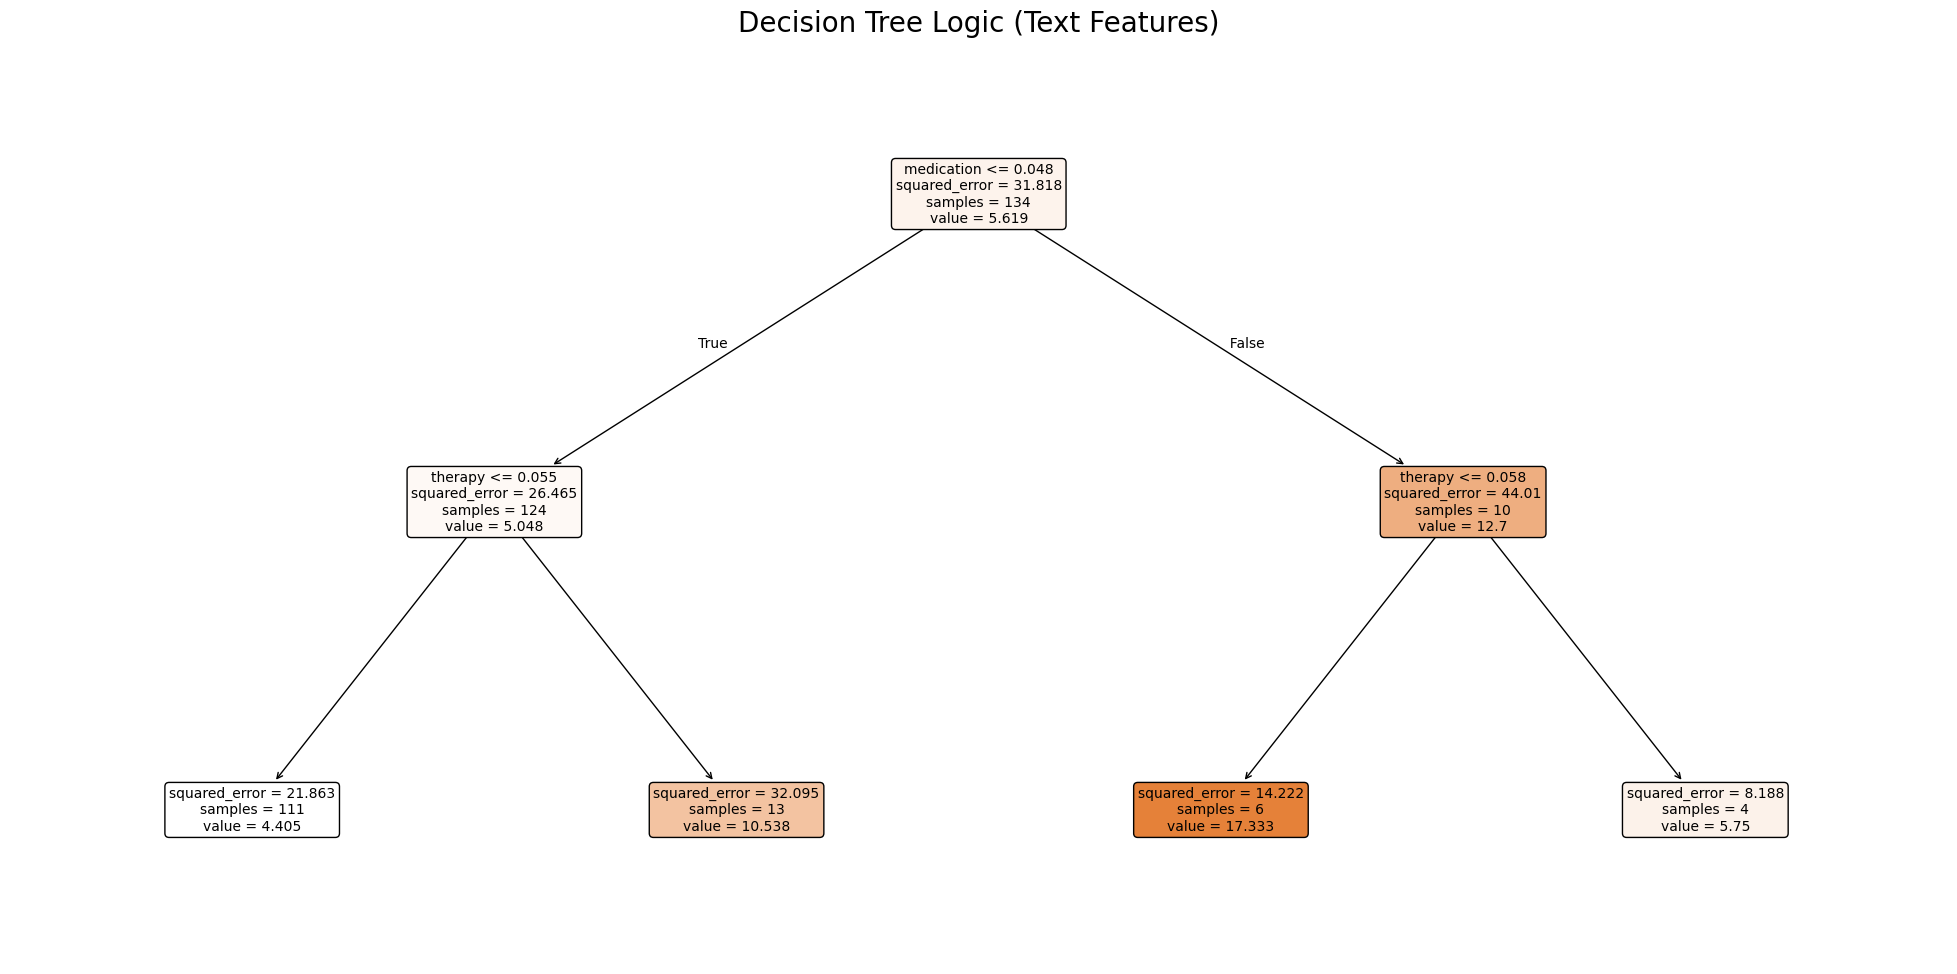

In [7]:
# 1.PREPARE FEATURE NAMES
# We need to combine TF-IDF words + VADER_Sentiment into one list
text_feature_names = list(tfidf.get_feature_names_out()) + ['VADER_Sentiment']

# 2.PLOT THE TREE
plt.figure(figsize=(25, 12))  # Big figure for clarity

plot_tree(final_model, 
          feature_names=text_feature_names, 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          max_depth=3) 

plt.title("Decision Tree Logic (Text Features)", fontsize=20)
plt.show()

### Step (c): Acoustic Features 

In [8]:
# Load Labels
labels_df = pd.read_csv(os.path.join(BASE_PATH, LABEL_FILE)).set_index('Participant_ID')

# PART C: ACOUSTIC FEATURE EXTRACTION & MODELING
print("Starting Acoustic Feature Extraction...")

X_audio = []
y_audio = []
audio_pids = [] 

acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)
files = [f for f in os.listdir(acoustics_path) if f.endswith('.csv')]

count = 0
for filename in files:
    try:
        pid = int(filename.split('_')[0])
        if pid in labels_df.index:
            df_part = pd.read_csv(os.path.join(acoustics_path, filename))
            
            # 1. Identify Acoustic Columns (eGeMAPS features usually have 'sma')
            acoustic_cols = [c for c in df_part.columns if 'sma' in c]
            
            if not acoustic_cols: continue

            # 2. Aggregate (Mean, Std, Min, Max)
            stats = df_part[acoustic_cols].agg(['mean', 'std', 'min', 'max'])
            
            # Flatten: [Feat1_mean, Feat1_std, ... FeatN_max]
            flat_feats = stats.unstack().values
            flat_feats = np.nan_to_num(flat_feats)
            
            X_audio.append(flat_feats)
            y_audio.append(labels_df.loc[pid, 'PHQ_Score'])
            audio_pids.append(pid)
            
            count += 1
            if count % 20 == 0: print(f"Processed audio for {count} participants...")

    except Exception as e:
        print(f"Error on {filename}: {e}")

X_audio = np.array(X_audio)
y_audio = np.array(y_audio)

# Generate Feature Names for Interpretation
feat_names_audio = []
for col in acoustic_cols:
    for stat in ['mean', 'std', 'min', 'max']:
        feat_names_audio.append(f"{col}_{stat}")

print(f"\nFinal Acoustic Data Shape: {X_audio.shape}")

# 4. DECISION TREE EXPERIMENT
# We have selected Depth 6 based on previous analysis
print("\nAcoustic Decision Tree Results (Selected Best Depth: 6)")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r_scores = []
re_scores = []

for train_idx, test_idx in kf.split(X_audio):
    X_tr, X_te = X_audio[train_idx], X_audio[test_idx]
    y_tr, y_te = y_audio[train_idx], y_audio[test_idx]
    
    # Train Model with Depth 6
    dt = DecisionTreeRegressor(max_depth=6, random_state=42)
    dt.fit(X_tr, y_tr)
    y_pred = dt.predict(X_te)
    
    # Metrics
    if np.std(y_pred) < 1e-5: r = 0
    else: r = pearsonr(y_te, y_pred)[0]
        
    # Relative Error Formula
    re = np.mean(np.abs(y_pred - y_te) / 24.0)
    
    r_scores.append(r)
    re_results_audio = re_scores.append(re) # Save for later if needed

print(f"Average Pearson r:   {np.mean(r_scores):.4f}")
print(f"Average Rel Error:   {np.mean(re_scores):.4f}")

# 5. INTERPRETABILITY
print("\nTop 10 Acoustic Features (Depth 6)")
final_dt_audio = DecisionTreeRegressor(max_depth=6, random_state=42)
final_dt_audio.fit(X_audio, y_audio)

importances = final_dt_audio.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(10):
    idx = indices[i]
    print(f"{i+1}. {feat_names_audio[idx]} ({importances[idx]:.4f})")

Starting Acoustic Feature Extraction...
Processed audio for 20 participants...
Processed audio for 40 participants...
Processed audio for 60 participants...
Processed audio for 80 participants...
Processed audio for 100 participants...
Processed audio for 120 participants...

Final Acoustic Data Shape: (134, 92)

Acoustic Decision Tree Results (Selected Best Depth: 6)
Average Pearson r:   0.0367
Average Rel Error:   0.2502

Top 10 Acoustic Features (Depth 6)
1. mfcc2_sma3_max (0.1236)
2. F1amplitudeLogRelF0_sma3nz_mean (0.0927)
3. shimmerLocaldB_sma3nz_std (0.0859)
4. shimmerLocaldB_sma3nz_mean (0.0814)
5. spectralFlux_sma3_min (0.0795)
6. logRelF0-H1-H2_sma3nz_mean (0.0777)
7. hammarbergIndex_sma3_std (0.0674)
8. spectralFlux_sma3_mean (0.0616)
9. logRelF0-H1-A3_sma3nz_max (0.0604)
10. F0semitoneFrom27.5Hz_sma3nz_max (0.0580)


C:\Users\agarw\AppData\Local\Temp\ipykernel_14580\3416317898.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_names, palette='magma')


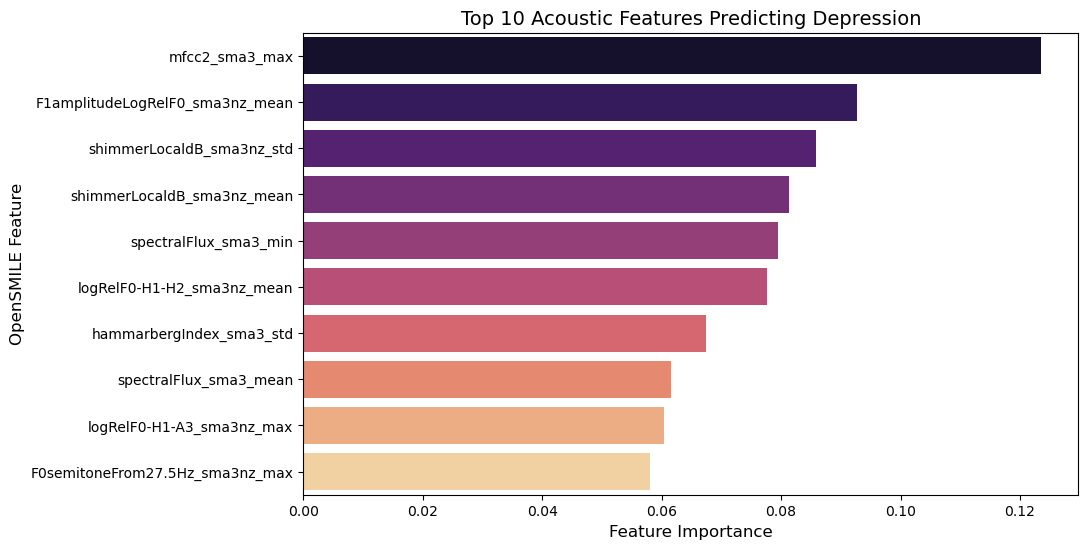

In [9]:
import seaborn as sns

# Get top 10 features from the Audio Decision Tree
importances = final_dt_audio.feature_importances_
indices = np.argsort(importances)[::-1][:10]
top_names = [feat_names_audio[i] for i in indices]
top_values = importances[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_values, y=top_names, palette='magma')
plt.title('Top 10 Acoustic Features Predicting Depression', fontsize=14)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('OpenSMILE Feature', fontsize=12)
plt.show()

### Step (d): Deep Learning Models 

In [10]:
# 1. SETUP GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# 2. DATA LOADING & PROCESSING
MAX_SEQ_LENGTH = 100  # For Text LSTM
MAX_WORDS = 5000      # Vocabulary size

print("Loading and Aligning Data...")
labels_df = pd.read_csv(os.path.join(BASE_PATH, LABEL_FILE)).set_index('Participant_ID')
acoustics_path = os.path.join(BASE_PATH, ACOUSTICS_FOLDER)
files = [f for f in os.listdir(acoustics_path) if f.endswith('.csv')]

# Lists to store aligned data
X_audio_features = [] # Will store Mean/Std/Min/Max
X_text_raw = []
y_list = []

for filename in files:
    try:
        pid = int(filename.split('_')[0])
        if pid in labels_df.index:
            # Load specific participant file
            df = pd.read_csv(os.path.join(acoustics_path, filename))
            
            # AUDIO: Aggregate Features (Fixes Data Loss)
            # Get only acoustic columns (exclude 'name', 'frameTime')
            cols = [c for c in df.columns if 'sma' in c]
            # Calculate Mean and Std for the whole interview
            # We use mean/std because LSTMs fail on sequences of 10,000+ steps
            stats = df[cols].agg(['mean', 'std'])
            # Flatten into a single vector (shape: [num_features * 2])
            flat_audio = stats.unstack().values
            flat_audio = np.nan_to_num(flat_audio) # Handle NaNs
            
            # TEXT: Raw String
            text_content = " ".join(df['Text'].astype(str).tolist())
            
            # TARGET
            score = labels_df.loc[pid, 'PHQ_Score']
            
            # Append only if everything worked
            X_audio_features.append(flat_audio)
            X_text_raw.append(text_content)
            y_list.append(score)
    except Exception as e:
        print(f"Skipping {filename}: {e}")

# Convert to Numpy
X_audio_np = np.array(X_audio_features, dtype=np.float32)
y_np = np.array(y_list, dtype=np.float32).reshape(-1, 1)

# TEXT TOKENIZATION
# Prepare text for LSTM
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_text_raw)
X_text_seq = tokenizer.texts_to_sequences(X_text_raw)
X_text_padded = pad_sequences(X_text_seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_text_np = np.array(X_text_padded, dtype=np.longlong) # PyTorch embedding needs Long

print(f"Data Loaded. Audio Shape: {X_audio_np.shape}, Text Shape: {X_text_np.shape}")


# 3. DEFINE MODELS

# Model A: Dense Network for Audio (Since input is Aggregated Stats)
class AudioNet(nn.Module):
    def __init__(self, input_dim):
        super(AudioNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3) # Helps prevent overfitting
        self.fc2 = nn.Linear(64, 16)
        self.fc3 = nn.Linear(16, 1)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# Model B: LSTM for Text
class TextNet(nn.Module):
    def __init__(self, vocab_size, embed_dim=50):
        super(TextNet, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, 32, batch_first=True)
        self.fc1 = nn.Linear(32, 1)
        
    def forward(self, x):
        x = self.embedding(x)
        _, (hn, _) = self.lstm(x) # Get last hidden state
        x = hn[-1]
        return self.fc1(x)

# Model C: Multimodal (Audio Dense + Text LSTM)
class MultiModalNet(nn.Module):
    def __init__(self, audio_dim, vocab_size, embed_dim=50):
        super(MultiModalNet, self).__init__()
        # Audio branch
        self.audio_fc = nn.Linear(audio_dim, 32)
        # Text branch
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.text_lstm = nn.LSTM(embed_dim, 32, batch_first=True)
        
        # Combined
        self.fc_out = nn.Linear(32 + 32, 1)
        self.relu = nn.ReLU()

    def forward(self, x_a, x_t):
        # Audio Path
        a = self.relu(self.audio_fc(x_a))
        # Text Path
        t = self.embedding(x_t)
        _, (hn, _) = self.text_lstm(t)
        t = hn[-1]
        # Concatenate
        combined = torch.cat((a, t), dim=1)
        return self.fc_out(combined)

# 4. TRAINING UTILS
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for batch in loader:
        optimizer.zero_grad()
        # Check if multimodal (tuple) or unimodal
        if len(batch) == 3: # Multimodal: Audio, Text, Label
            xa, xt, y = batch
            xa, xt, y = xa.to(device), xt.to(device), y.to(device)
            preds = model(xa, xt)
        else: # Unimodal: X, Label
            x, y = batch
            x, y = x.to(device), y.to(device)
            preds = model(x)
            
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

def evaluate(model, X_data, y_data, is_multi=False):
    model.eval()
    with torch.no_grad():
        if is_multi:
            xa = torch.tensor(X_data[0], dtype=torch.float32).to(device)
            xt = torch.tensor(X_data[1], dtype=torch.long).to(device)
            preds = model(xa, xt).cpu().numpy().flatten()
        else:
            # Check dtype based on input (Audio=Float, Text=Long)
            dtype = torch.long if X_data.dtype == 'int64' or X_data.dtype == 'int32' else torch.float32
            x = torch.tensor(X_data, dtype=dtype).to(device)
            preds = model(x).cpu().numpy().flatten()
    return preds

# 5. CROSS VALIDATION LOOP
print("\nStarting 5-Fold Cross Validation...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {'Audio': [], 'Text': [], 'Multimodal': []}
re_results = {'Audio': [], 'Text': [], 'Multimodal': []}

fold = 1
for train_idx, test_idx in kf.split(X_audio_np):
    # 1. Split Data
    X_a_train, X_a_test = X_audio_np[train_idx], X_audio_np[test_idx]
    X_t_train, X_t_test = X_text_np[train_idx], X_text_np[test_idx]
    y_train, y_test = y_np[train_idx], y_np[test_idx]
    
    # 2. Scale Audio (Inside Loop to prevent leakage)
    scaler = StandardScaler()
    X_a_train = scaler.fit_transform(X_a_train)
    X_a_test = scaler.transform(X_a_test)
    
    # 3. Create Tensors
    X_a_train_t = torch.tensor(X_a_train, dtype=torch.float32)
    X_t_train_t = torch.tensor(X_t_train, dtype=torch.long)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    
    # 4. Loaders
    bs = 8 # Batch size
    dl_a = DataLoader(TensorDataset(X_a_train_t, y_train_t), batch_size=bs, shuffle=True)
    dl_t = DataLoader(TensorDataset(X_t_train_t, y_train_t), batch_size=bs, shuffle=True)
    dl_m = DataLoader(TensorDataset(X_a_train_t, X_t_train_t, y_train_t), batch_size=bs, shuffle=True)
    
    # 5. Initialize Models
    model_a = AudioNet(input_dim=X_a_train.shape[1]).to(device)
    model_t = TextNet(vocab_size=MAX_WORDS).to(device)
    model_m = MultiModalNet(audio_dim=X_a_train.shape[1], vocab_size=MAX_WORDS).to(device)
    
    crit = nn.MSELoss()
    
    # 6. Train & Predict
    # Audio
    opt = optim.Adam(model_a.parameters(), lr=0.001)
    for _ in range(30): train_epoch(model_a, dl_a, opt, crit)
    pred_a = evaluate(model_a, X_a_test, y_test)
    
    # Text
    opt = optim.Adam(model_t.parameters(), lr=0.001)
    for _ in range(20): train_epoch(model_t, dl_t, opt, crit)
    pred_t = evaluate(model_t, X_t_test, y_test)
    
    # Multimodal
    opt = optim.Adam(model_m.parameters(), lr=0.001)
    for _ in range(20): train_epoch(model_m, dl_m, opt, crit)
    pred_m = evaluate(model_m, (X_a_test, X_t_test), y_test, is_multi=True)
    
    # 7. Store Metrics
    for name, p in [('Audio', pred_a), ('Text', pred_t), ('Multimodal', pred_m)]:
        # Pearson R
        if np.std(p) < 1e-5: r=0
        else: r = pearsonr(y_test.flatten(), p)[0]
        results[name].append(r)
        
        # Relative Error
        re = np.mean(np.abs(p - y_test.flatten()) / 24.0)
        re_results[name].append(re)

    print(f"Fold {fold} done.")
    fold += 1

print("\n" + "="*50)
print(f"{'Model Type':<15} {'Avg Pearson r':<15} {'Avg Rel Error':<15}")
print("-" * 50)
for name in ['Audio', 'Text', 'Multimodal']:
    avg_r = np.mean(results[name])
    avg_re = np.mean(re_results[name])
    print(f"{name:<15} {avg_r:.4f}          {avg_re:.4f}")
print("="*50)

Running on: NVIDIA GeForce RTX 4070 Laptop GPU
Loading and Aligning Data...
Data Loaded. Audio Shape: (134, 46), Text Shape: (134, 100)

Starting 5-Fold Cross Validation...
Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.

Model Type      Avg Pearson r   Avg Rel Error  
--------------------------------------------------
Audio           0.0896          0.1988
Text            0.1286          0.1878
Multimodal      0.1231          0.1891


### Step (e): Explainable ML (SHAP) 


Starting Part (e) SHAP Explanation (PyTorch)
Calculating SHAP values (this might take a minute)...


  0%|          | 0/3 [00:00<?, ?it/s]

Generating Summary Plot...


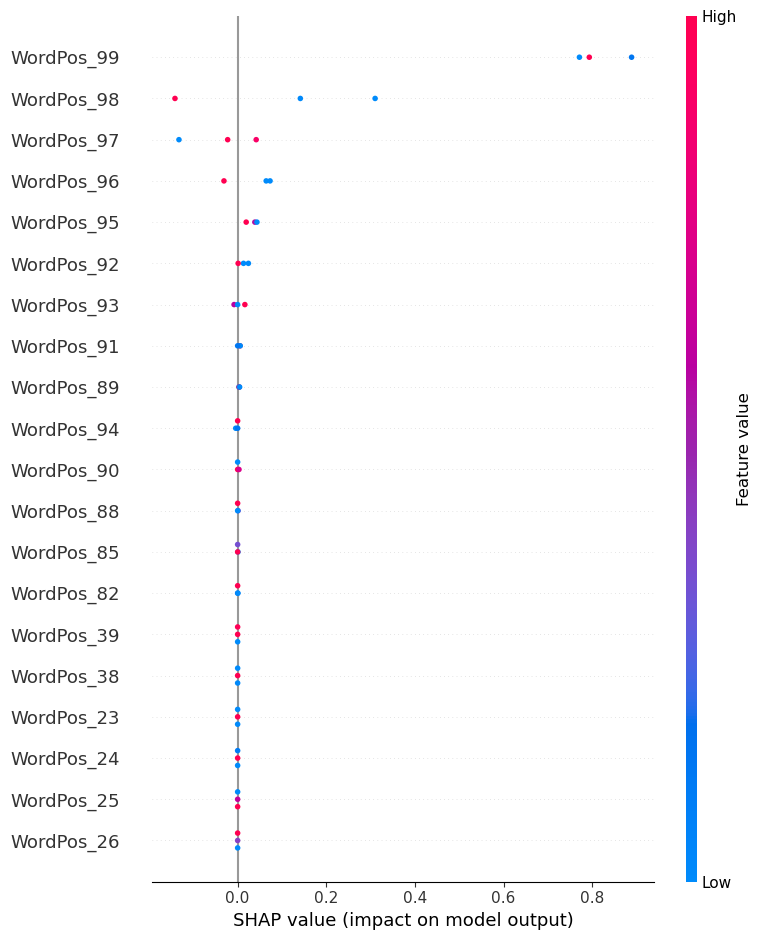


Top words impacting depression score for Participant #1:
Word ID    Word String     Impact Score
---------------------------------------------
53         well            0.8887
44         time            0.1414
5          a               0.0731
197        long            0.0418
25         for             0.0388


In [ ]:
print("\nStarting Part (e) SHAP Explanation (PyTorch)")

# 1. Setup Data
# Use background data from the text numpy array we created in Part (d)
# We use a small background set (e.g., 20 samples) to keep it fast
background_indices = np.random.choice(len(X_text_np), 20, replace=False)
background_data = X_text_np[background_indices]
test_samples = X_text_np[:3] # Explain first 3 predictions

# 2. Define Wrapper Function
# SHAP passes numpy arrays, we need to convert to PyTorch Tensors
def pytorch_predictor(data):
    # Convert numpy -> torch tensor -> move to GPU
    tensor_data = torch.tensor(data, dtype=torch.long).to(device)
    
    model_t.eval() # Use the text model trained in Part (d)
    with torch.no_grad():
        preds = model_t(tensor_data)
    
    return preds.cpu().numpy().flatten()

# 3. Initialize & Run Explainer
# Note: KernelExplainer is model-agnostic. It perturbs inputs and checks outputs.
print("Calculating SHAP values...")
explainer = shap.KernelExplainer(pytorch_predictor, background_data)
shap_values = explainer.shap_values(test_samples)

# Handle list output (SHAP sometimes returns list for regression)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# 4. Visualization
print("Generating Summary Plot...")
shap.summary_plot(shap_values, test_samples, feature_names=[f"WordPos_{i}" for i in range(test_samples.shape[1])])

# 5. Decode Top Features for the first sample
print("\nTop words impacting depression score for Participant #1:")
reverse_word_map = dict(map(reversed, tokenizer.word_index.items()))

# Get indices of words with highest impact (absolute value)
sample_idx = 0
impact_indices = np.argsort(np.abs(shap_values[sample_idx]))[-5:][::-1]

print(f"{'Word ID':<10} {'Word String':<15} {'Impact Score'}")
print("-" * 45)
for idx in impact_indices:
    word_id = test_samples[sample_idx][idx]
    # Lookup word (0 is padding)
    word = reverse_word_map.get(word_id, "[PAD]")
    impact = shap_values[sample_idx][idx]
    print(f"{word_id:<10} {word:<15} {impact:.4f}")

### Step (f): 

In [12]:
# 1. GPU SETUP
print("Part (f) Bonus: Transformer (BERT) on GPU")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. LOAD BERT
print("Loading DistilBERT...")
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)
bert_model.eval()

# 3. EXTRACT EMBEDDINGS
# X_text_raw was created in Step (d) - List of strings
if 'X_text_raw' not in locals():
    print("Error: Please run Step (d) first to load the text data.")
else:
    print(f"Extracting embeddings for {len(X_text_raw)} participants...")
    X_bert = []
    
    # Batch processing to speed it up
    BATCH_SIZE = 16
    
    for i in range(0, len(X_text_raw), BATCH_SIZE):
        batch_texts = X_text_raw[i : i + BATCH_SIZE]
        
        # Tokenize
        inputs = bert_tokenizer(batch_texts, return_tensors="pt", max_length=512, truncation=True, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = bert_model(**inputs)
        
        # Use [CLS] token embedding (index 0)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        X_bert.append(cls_embeddings)
        
        sys.stdout.write(f"\rProcessed {min(i + BATCH_SIZE, len(X_text_raw))}...")
        sys.stdout.flush()
        
    X_bert = np.vstack(X_bert)
    # Reuse y_np from Step (d)
    y_target = y_np.flatten()
    
    print(f"\nBERT Features Shape: {X_bert.shape}")

    # 4. TRAIN REGRESSOR (Ridge)
    print("\nTransformer Results (Ridge Regression)")
    print(f"{'Fold':<10} {'Pearson r':<15} {'Rel Error':<15}")
    print("-" * 40)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    bert_r_scores = []
    bert_re_scores = [] # Renamed to avoid conflict with Part (d)
    fold = 1

    for train_idx, test_idx in kf.split(X_bert):
        X_tr, X_te = X_bert[train_idx], X_bert[test_idx]
        y_tr, y_te = y_target[train_idx], y_target[test_idx]
        
        # Ridge is good for high-dimensional embeddings
        clf = Ridge(alpha=10.0) 
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        
        # Metrics
        if np.std(y_pred) < 1e-5: r = 0
        else: r = pearsonr(y_te, y_pred)[0]
        
        re = np.mean(np.abs(y_pred - y_te) / 24.0)
        
        bert_r_scores.append(r)
        bert_re_scores.append(re)
        
        print(f"{fold:<10} {r:.4f}          {re:.4f}")
        fold += 1

    print("-" * 40)
    print(f"AVG       {np.mean(bert_r_scores):.4f}          {np.mean(bert_re_scores):.4f}")
    print("=" * 40)

Part (f) Bonus: Transformer (BERT) on GPU
Loading DistilBERT...
Extracting embeddings for 134 participants...
Processed 134...
BERT Features Shape: (134, 768)

Transformer Results (Ridge Regression)
Fold       Pearson r       Rel Error      
----------------------------------------
1          -0.1404          0.1825
2          -0.0467          0.1850
3          0.0053          0.2452
4          0.0209          0.1721
5          -0.2415          0.2556
----------------------------------------
AVG       -0.0805          0.2081


Generating Plots for Presentation


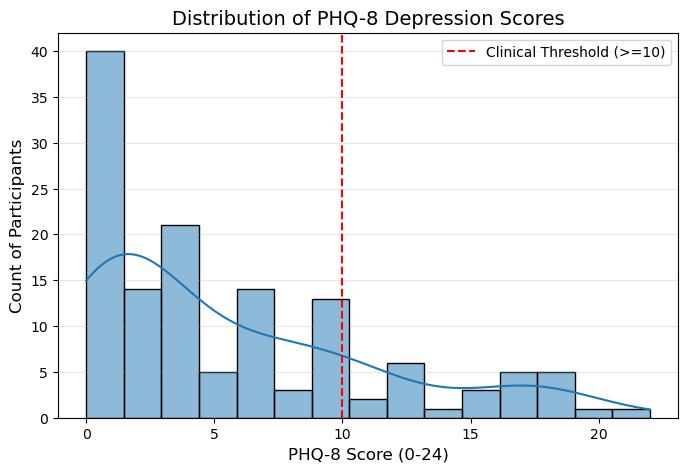

C:\Users\agarw\AppData\Local\Temp\ipykernel_14580\67165482.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_names, palette='viridis')


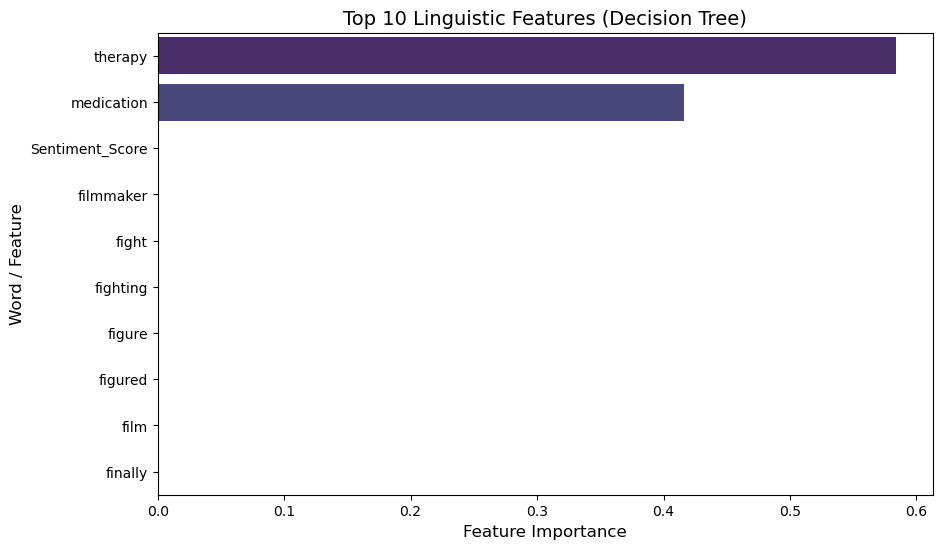

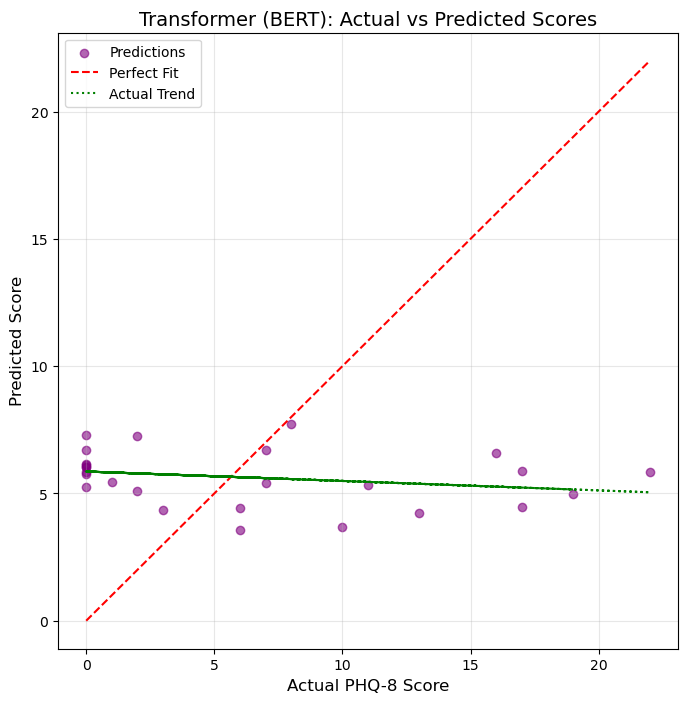

In [13]:
print("Generating Plots for Presentation")

# 1. DATASET DISTRIBUTION PLOT
# Shows the class balance/imbalance
if 'y_np' in locals():
    plt.figure(figsize=(8, 5))
    sns.histplot(y_np, bins=15, kde=True, color='skyblue', edgecolor='black')
    plt.title('Distribution of PHQ-8 Depression Scores', fontsize=14)
    plt.xlabel('PHQ-8 Score (0-24)', fontsize=12)
    plt.ylabel('Count of Participants', fontsize=12)
    # Clinical threshold for depression is typically 10
    plt.axvline(x=10, color='red', linestyle='--', label='Clinical Threshold (>=10)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# 2. DECISION TREE FEATURE IMPORTANCE
# Visualizing what words the text tree found important (from Part b)
if 'final_model' in locals() and 'tfidf' in locals():
    importances = final_model.feature_importances_
    # Get top 10 features
    indices = np.argsort(importances)[::-1][:10]
    
    vocab = tfidf.get_feature_names_out()
    top_names = []
    top_values = []
    
    for i in indices:
        if i < len(vocab):
            top_names.append(vocab[i])
            top_values.append(importances[i])
        # (VADER sentiment was appended at the end in previous steps if used)
        elif i == len(vocab): 
            top_names.append("Sentiment_Score")
            top_values.append(importances[i])

    if top_values:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_values, y=top_names, palette='viridis')
        plt.title('Top 10 Linguistic Features (Decision Tree)', fontsize=14)
        plt.xlabel('Feature Importance', fontsize=12)
        plt.ylabel('Word / Feature', fontsize=12)
        plt.show()

# 3. BERT MODEL PREDICTIONS (SCATTER PLOT)
# Visualizes the performance of the last fold from Part (f)
if 'y_te' in locals() and 'y_pred' in locals():
    plt.figure(figsize=(8, 8))
    # Create scatter plot
    plt.scatter(y_te, y_pred, alpha=0.6, color='purple', label='Predictions')
    
    # Draw the "Perfect Prediction" line (x=y)
    min_val = min(y_te.min(), y_pred.min())
    max_val = max(y_te.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')
    
    # Calculate trend line
    m, b = np.polyfit(y_te, y_pred, 1)
    plt.plot(y_te, m*y_te + b, color='green', linestyle=':', label=f'Actual Trend')

    plt.title('Transformer (BERT): Actual vs Predicted Scores', fontsize=14)
    plt.xlabel('Actual PHQ-8 Score', fontsize=12)
    plt.ylabel('Predicted Score', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()